# Descriptive Layers


## Library import and settings

In [1]:
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("viridis")
pd.set_option("display.float_format", "{:.4f}".format)


## Constant

In [2]:
DATASET_BIRTHDAY = "2025-09-22"


##

## Load the Dataset

In [3]:
listings = pd.read_parquet("../data/processed/listings_clean.parquet")


In [4]:
listings.info()


<class 'pandas.DataFrame'>
RangeIndex: 2852 entries, 0 to 2851
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              2852 non-null   int64         
 1   name                            2852 non-null   str           
 2   host_id                         2852 non-null   int64         
 3   host_name                       2849 non-null   str           
 4   neighbourhood                   2852 non-null   int64         
 5   latitude                        2852 non-null   float64       
 6   longitude                       2852 non-null   float64       
 7   room_type                       2852 non-null   str           
 8   price                           2537 non-null   float64       
 9   minimum_nights                  2852 non-null   int64         
 10  number_of_reviews               2852 non-null   int64         
 11  last_review    

## Date transcription

In [5]:
listings["review_year"] = listings["last_review"].dt.year
listings["review_month"] = listings["last_review"].dt.month
listings["days_since_review"] = (
    pd.Timestamp(DATASET_BIRTHDAY) - listings["last_review"]
).dt.days


## Useful structures

In [6]:
NUMERIC_COLUMNS = [
    "latitude",
    "longitude",
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "number_of_reviews_ltm",
    "review_year",
    "review_month",
    "days_since_review",
]

CATEGORICAL_COLUMNS = [
    "neighbourhood",
    "room_type",
]


## Univariate Analysis

### Numeric Columns Analysis


#### Distribution

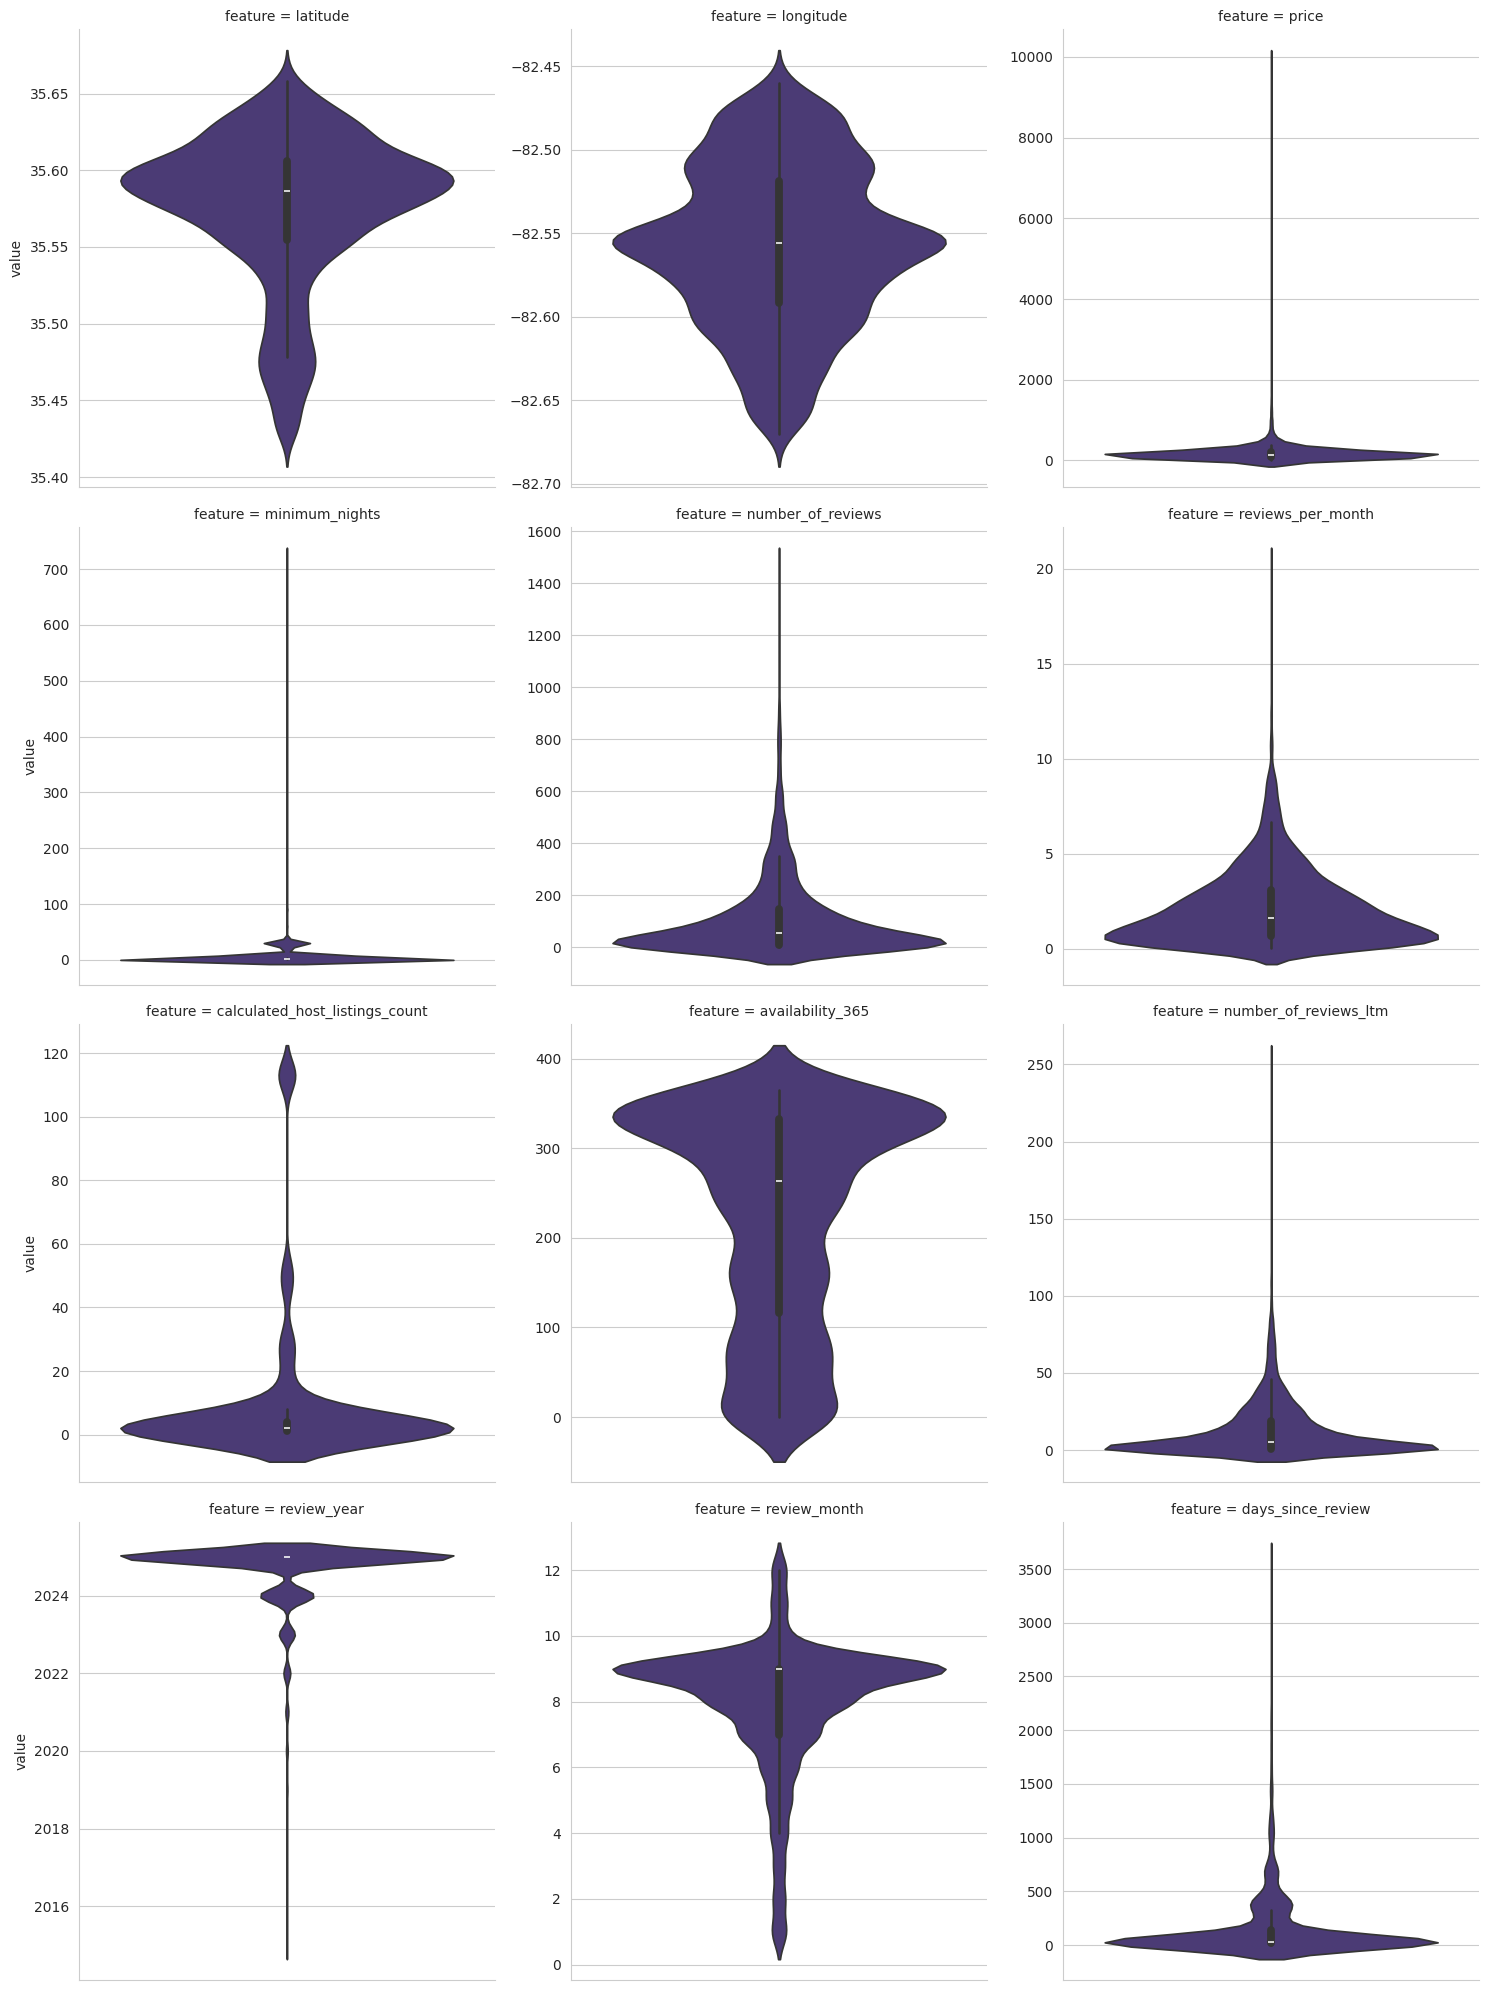

In [7]:
sns.catplot(
    data=listings[NUMERIC_COLUMNS].melt(var_name="feature", value_name="value"),
    y="value",
    kind="violin",
    col="feature",
    col_wrap=3,
    sharey=False,
)


In [8]:
listings[NUMERIC_COLUMNS].describe()


,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,review_year,review_month,days_since_review
count,2852.0000,2852.0000,2537.0000,2852.0000,2852.0000,2609.0000,2852.0000,2852.0000,2852.0000,2609.0000,2609.0000,2609.0000
mean,35.5749,-82.5575,196.3839,6.2013,113.7156,2.1780,9.6466,223.5550,12.9632,2024.6704,7.9563,159.9935
std,0.0496,0.0484,405.6750,20.5200,157.7760,1.9916,23.3005,122.2471,18.2980,0.8653,2.0104,319.4339
min,35.4271,-82.6699,18.0000,1.0000,0.0000,0.0200,1.0000,0.0000,0.0000,2015.0000,1.0000,1.0000
25%,35.5548,-82.5918,95.0000,1.0000,11.0000,0.6900,1.0000,116.0000,1.0000,2025.0000,7.0000,15.0000
50%,35.5868,-82.5559,133.0000,2.0000,57.0000,1.6400,2.0000,263.0000,5.0000,2025.0000,9.0000,29.0000
75%,35.6058,-82.5190,211.0000,2.0000,147.0000,3.0900,4.0000,332.0000,19.0000,2025.0000,9.0000,141.0000
max,35.6581,-82.4602,9999.0000,730.0000,1473.0000,20.2900,113.0000,365.0000,255.0000,2025.0000,12.0000,3612.0000


#### Outliers

In [9]:
for col in [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "calculated_host_listings_count",
]:
    print(f"\n{col} TOP 5")
    display(listings.nlargest(5, col))

    print(f"{col} BOTTOM 5")
    display(listings.nsmallest(5, col))



price TOP 5


,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,review_year,review_month,days_since_review
2768,1450886572499190369,Kasa | Queen Room | Asheville,88566861,Kasa,28801,35.6008,-82.5444,Entire home/apt,9999.0000,1,3,2025-09-05,1.2000,5,263,3,2025.0000,9.0000,17.0000
2770,1451419550411824711,Kasa | Double Twin Room | Asheville,88566861,Kasa,28801,35.6006,-82.5441,Entire home/apt,9999.0000,1,8,2025-09-11,3.0400,5,277,8,2025.0000,9.0000,11.0000
2776,1452315568921110412,Kasa | Queen Room with Kitchenette | Asheville,88566861,Kasa,28801,35.6020,-82.5437,Private room,9999.0000,1,8,2025-09-16,3.5800,5,279,8,2025.0000,9.0000,6.0000
2594,1339091513653409760,Asheville River Cabins,477251437,Asheville River Cabins,28704,35.4903,-82.5722,Entire home/apt,6847.0000,1,0,NaT,NaN,8,358,0,NaN,NaN,NaN
2590,1334016503347045444,Test- Do Not Book,671103351,Richa,28806,35.5847,-82.5921,Entire home/apt,2558.0000,1,0,NaT,NaN,1,365,0,NaN,NaN,NaN


price BOTTOM 5


,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,review_year,review_month,days_since_review
502,25138871,Tent Site #1 @The Baying Hound Campground,151279507,Amanda Elizabeth,28806,35.6116,-82.6052,Entire home/apt,18.0000,1,101,2025-07-12,1.1300,20,90,2,2025.0000,7.0000,72.0000
488,24697002,Tent Site #2 @The Baying Hound Campground,151279507,Amanda Elizabeth,28806,35.6129,-82.6038,Entire home/apt,20.0000,1,54,2022-07-04,0.6000,20,176,0,2022.0000,7.0000,1176.0000
533,26634224,Tent Site #4 @The Baying Hound Campground,151279507,Amanda Elizabeth,28806,35.6115,-82.6052,Entire home/apt,20.0000,1,80,2025-09-01,0.9100,20,176,3,2025.0000,9.0000,21.0000
966,42980053,Tent Site #6 @The Baying Hound Campground,151279507,Amanda Elizabeth,28806,35.6122,-82.6043,Entire home/apt,20.0000,1,75,2025-07-12,1.1700,20,358,2,2025.0000,7.0000,72.0000
968,42981397,Hammock Site @The Baying Hound Campground,151279507,Amanda Elizabeth,28806,35.6123,-82.6050,Entire home/apt,20.0000,1,27,2025-08-29,0.4200,20,364,2,2025.0000,8.0000,24.0000



minimum_nights TOP 5


...

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,review_year,review_month,days_since_review
55,3445336,Bungalow in Downtown Asheville,17363326,Michael,28801,35.5918,-82.5463,Entire home/apt,NaN,30,0,NaT,NaN,2,365,0,NaN,NaN,NaN
72,4809731,Stylish house near Downtown & Mission Hospital,12679902,Summer,28805,35.5873,-82.5354,Entire home/apt,104.0000,30,0,NaT,NaN,1,325,0,NaN,NaN,NaN
282,17638102,True Asheville B&B- Wall Street Room- 2nd Floor,1786031,Emily Elizabeth,28801,35.6046,-82.5506,Private room,136.0000,20,0,NaT,NaN,2,90,0,NaN,NaN,NaN
578,28843687,West Asheville Haven,6686569,Jaclyn,28806,35.5708,-82.5899,Entire home/apt,261.0000,28,0,NaT,NaN,1,263,0,NaN,NaN,NaN
959,42757547,S. Asheville Condo - Close to Blue Ridge Parkway!,21265399,Allison,28803,35.5091,-82.5293,Entire home/apt,146.0000,30,0,NaT,NaN,1,356,0,NaN,NaN,NaN



calculated_host_listings_count TOP 5


,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,review_year,review_month,days_since_review
633,31260007,South Slope Rooftop Patio Townhome with Elevator,167186184,Towns,28801,35.5864,-82.5534,Entire home/apt,252.0000,2,171,2025-07-31,2.1200,113,331,12,2025.0000,7.0000,53.0000
635,31267687,Your Downtown Asheville Pet-Friendly Oasis,167186184,Towns,28801,35.5932,-82.5574,Entire home/apt,133.0000,2,211,2025-08-17,2.6000,113,357,19,2025.0000,8.0000,36.0000
636,31315518,Rare Three Bedroom in Downtown Asheville,167186184,Towns,28801,35.5922,-82.5560,Entire home/apt,422.0000,2,94,2025-09-07,1.1600,113,331,6,2025.0000,9.0000,15.0000
637,31318558,Awesome Fifth Floor Views,167186184,Towns,28801,35.5921,-82.5574,Entire home/apt,148.0000,2,181,2025-08-17,2.2400,113,350,8,2025.0000,8.0000,36.0000
638,31318559,Two Bedroom Downtown with Balcony,167186184,Towns,28801,35.5914,-82.5569,Entire home/apt,265.0000,2,86,2025-05-26,1.0600,113,354,2,2025.0000,5.0000,119.0000


calculated_host_listings_count BOTTOM 5


,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,review_year,review_month,days_since_review
2,209068,Terrace Cottage,1029919,Kevin,28804,35.6176,-82.5518,Entire home/apt,90.0000,30,67,2025-05-03,0.3900,1,268,2,2025.0000,5.0000,142.0000
4,314540,Asheville Urban Farmhouse Entire Home 4.6 mi t...,381660,Tom,28806,35.5856,-82.6273,Entire home/apt,221.0000,1,36,2025-06-23,0.2200,1,180,7,2025.0000,6.0000,91.0000
5,427497,Luxurious Mountain Guest Suite Apartment,1909922,Milan,28803,35.4909,-82.4860,Entire home/apt,148.0000,2,47,2023-09-04,0.3000,1,359,0,2023.0000,9.0000,749.0000
9,621243,The Birdhouse\nSweet suite! Downtown Roof top ...,3079174,Molly,28801,35.6041,-82.5489,Entire home/apt,137.0000,30,150,2025-09-01,1.6400,1,270,4,2025.0000,9.0000,21.0000
10,660702,Cozy Asheville Retreat,3335271,Brady,28804,35.6213,-82.5530,Entire home/apt,59.0000,1,844,2025-08-29,7.2200,1,338,45,2025.0000,8.0000,24.0000


### Categorical Columns Analysis

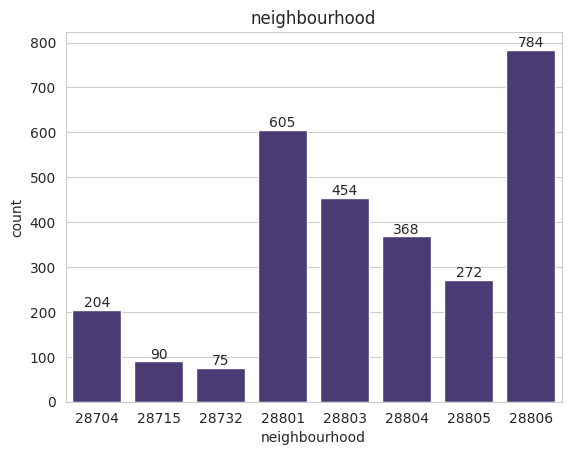

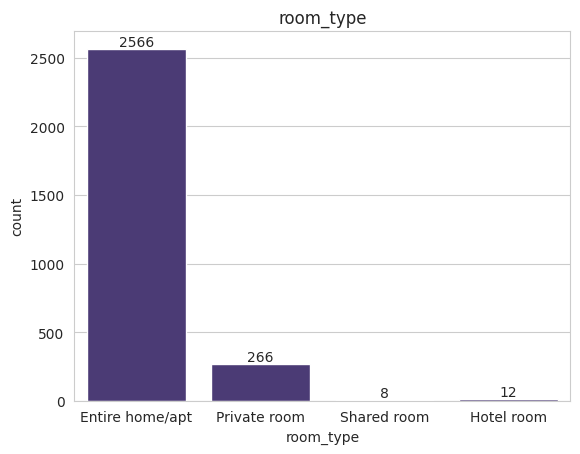

In [10]:
for col in CATEGORICAL_COLUMNS:
    ax = sns.countplot(data=listings, x=col)

    for container in ax.containers:
        ax.bar_label(container)

    plt.title(col)
    plt.show()


## Bivariate Analysis


### Cleaned Dataset

In [11]:
cleaned_listings = listings[NUMERIC_COLUMNS].drop(
    columns=[
        "latitude",
        "longitude",
        "number_of_reviews",
        "reviews_per_month",
        "review_year",
        "review_month",
    ]
)

cleaned_listings = cleaned_listings[
    (cleaned_listings["price"] < cleaned_listings["price"].quantile(0.99))
    & (
        cleaned_listings["minimum_nights"]
        < cleaned_listings["minimum_nights"].quantile(0.99)
    )
    & (
        cleaned_listings["number_of_reviews_ltm"]
        < cleaned_listings["number_of_reviews_ltm"].quantile(0.99)
    )
    & (
        cleaned_listings["days_since_review"]
        < cleaned_listings["days_since_review"].quantile(0.99)
    )
].copy()


### Correlation map

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5]),
 [Text(0.5, 0, 'latitude'),
  Text(1.5, 0, 'longitude'),
  Text(2.5, 0, 'price'),
  Text(3.5, 0, 'minimum_nights'),
  Text(4.5, 0, 'number_of_reviews'),
  Text(5.5, 0, 'reviews_per_month'),
  Text(6.5, 0, 'calculated_host_listings_count'),
  Text(7.5, 0, 'availability_365'),
  Text(8.5, 0, 'number_of_reviews_ltm'),
  Text(9.5, 0, 'days_since_review')])

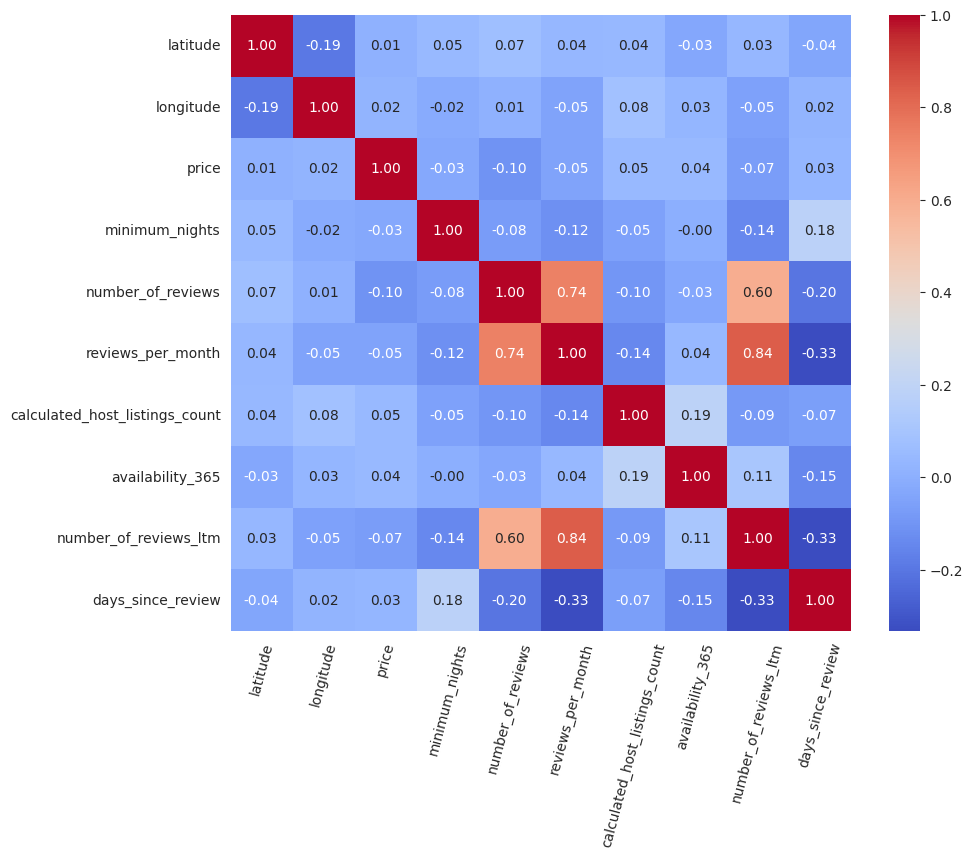

In [12]:
corr_matrix = (
    listings[NUMERIC_COLUMNS].drop(columns=["review_month", "review_year"]).corr()
)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.xticks(rotation=75)


In [13]:
cleaned_listings["room_type"] = listings["room_type"]
cleaned_listings["neighbourhood"] = listings["neighbourhood"]


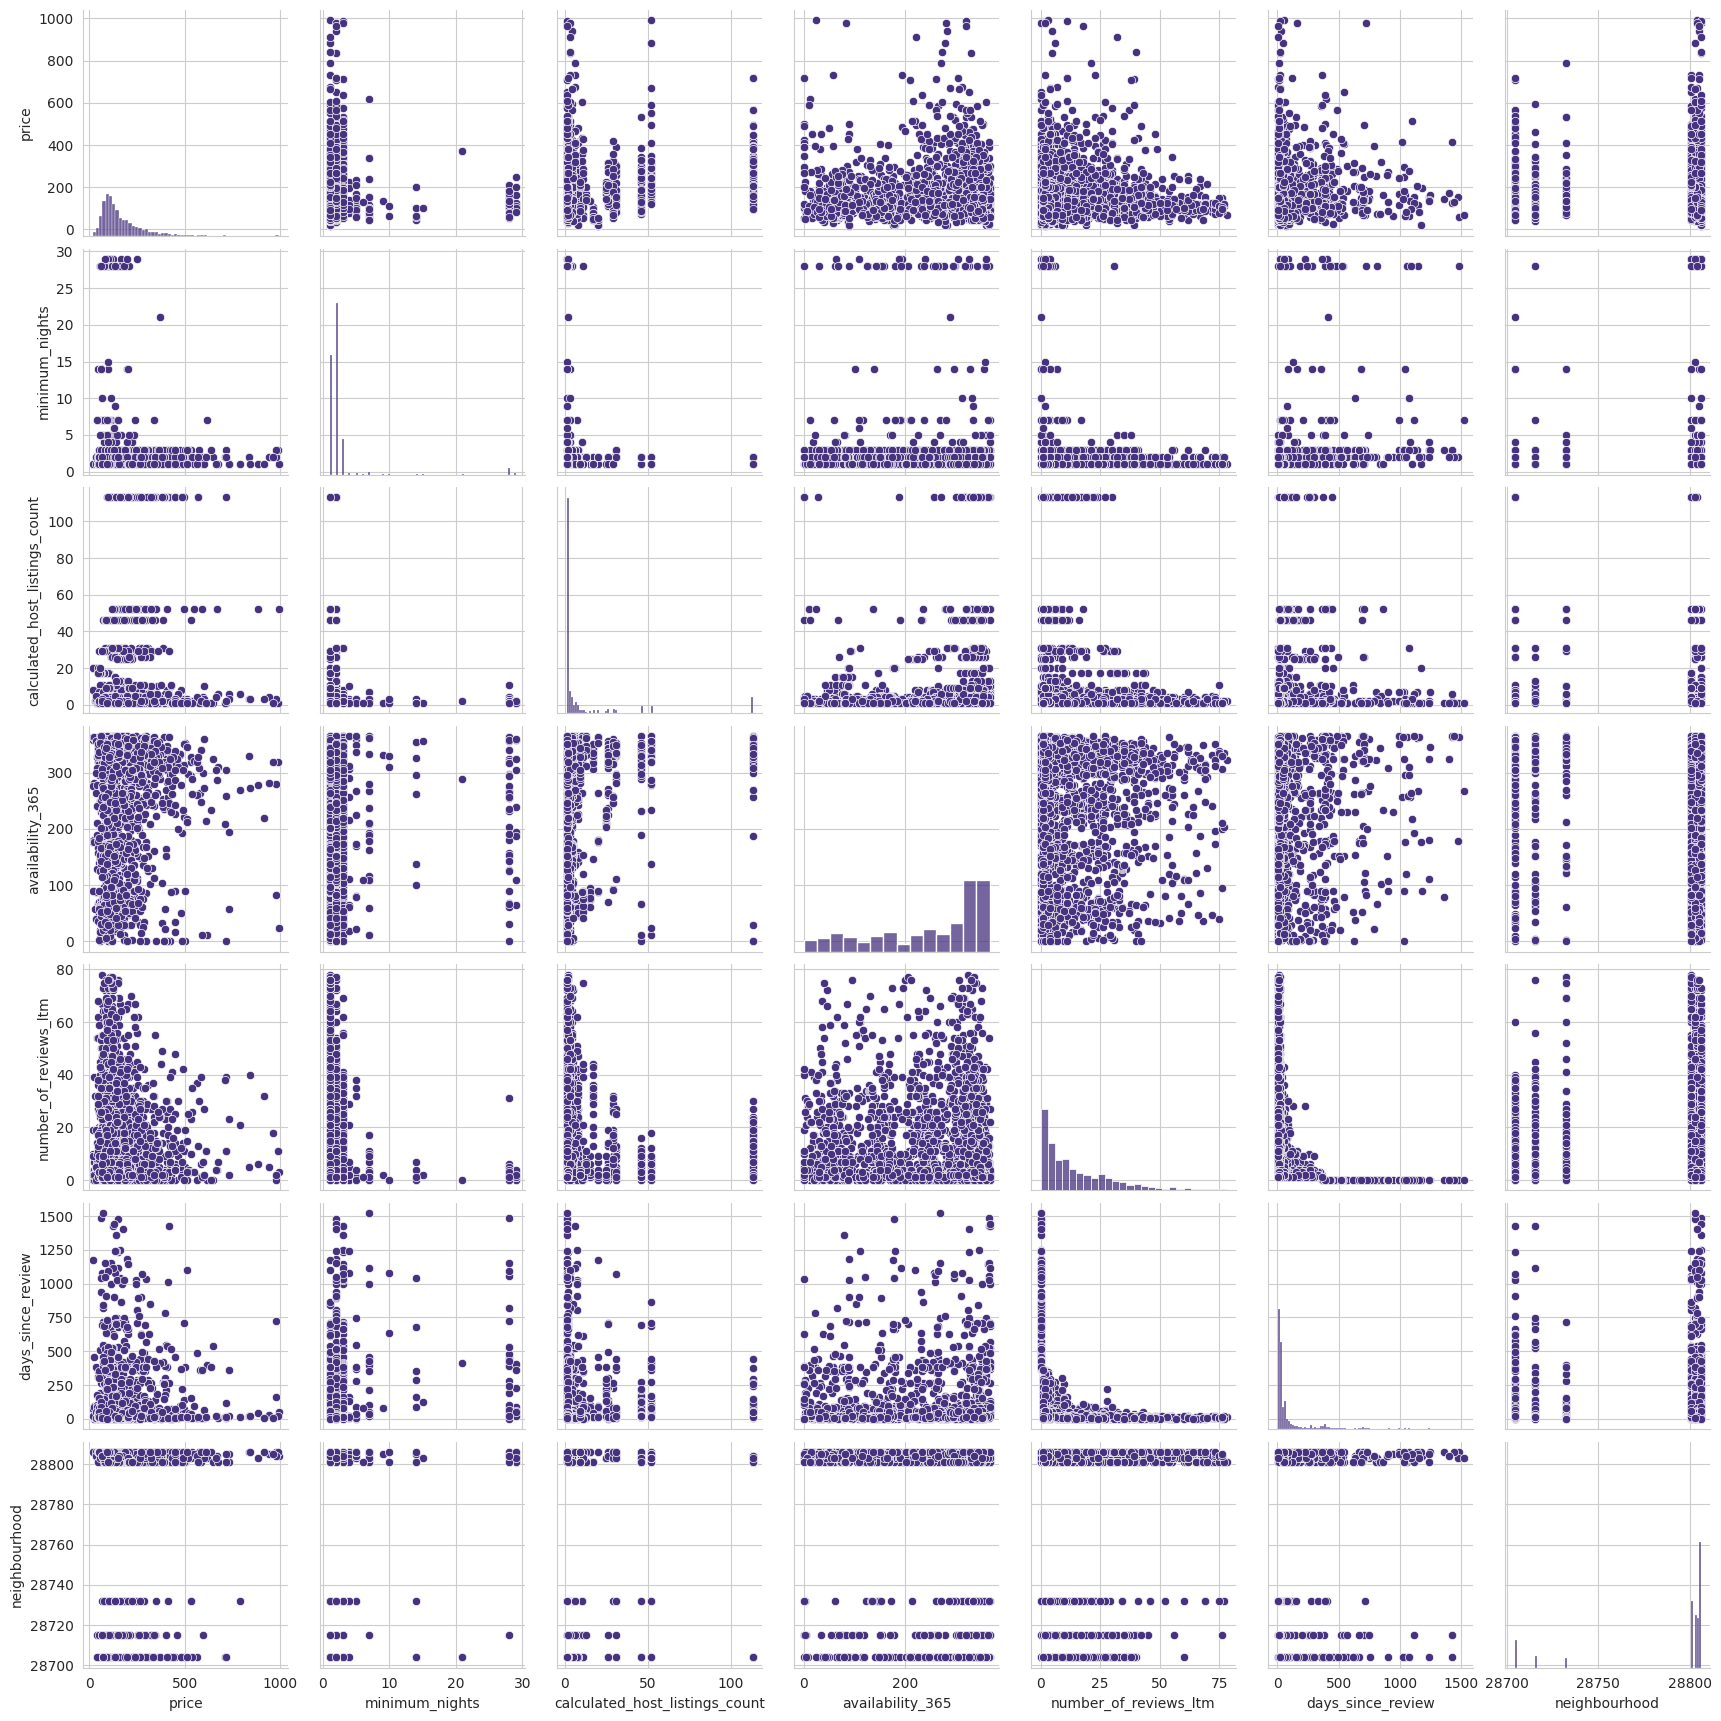

In [14]:
sns.pairplot(data=cleaned_listings)


### `price` vs `room_type`

<Axes: xlabel='room_type', ylabel='price'>

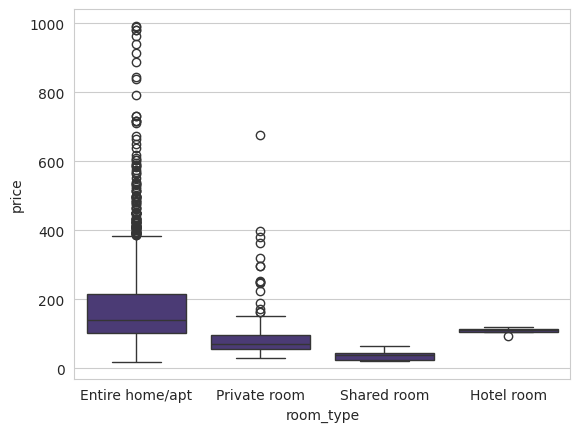

In [15]:
sns.boxplot(data=cleaned_listings, x="room_type", y="price")


### `price` vs `neighbourhood`

<Axes: xlabel='neighbourhood', ylabel='price'>

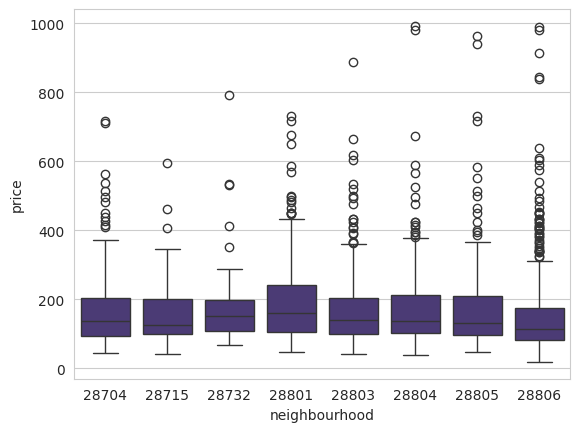

In [16]:
sns.boxplot(data=cleaned_listings, x="neighbourhood", y="price")


### `number_of_reviews_ltm` vs `room_type`


<Axes: xlabel='room_type', ylabel='number_of_reviews_ltm'>

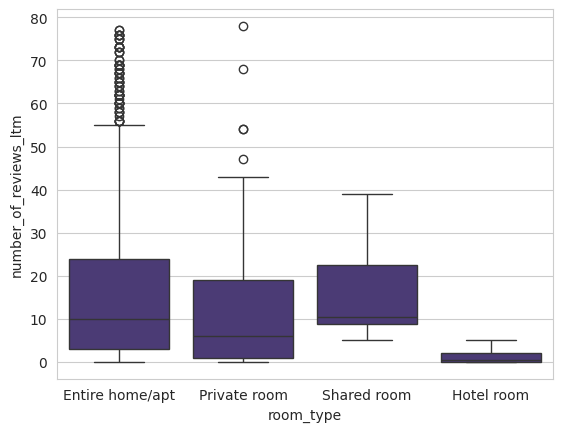

In [22]:
sns.boxplot(data=cleaned_listings, x="room_type", y="number_of_reviews_ltm")


### `number_of_reviews_ltm` vs `neighbourhood`


<Axes: xlabel='neighbourhood', ylabel='number_of_reviews_ltm'>

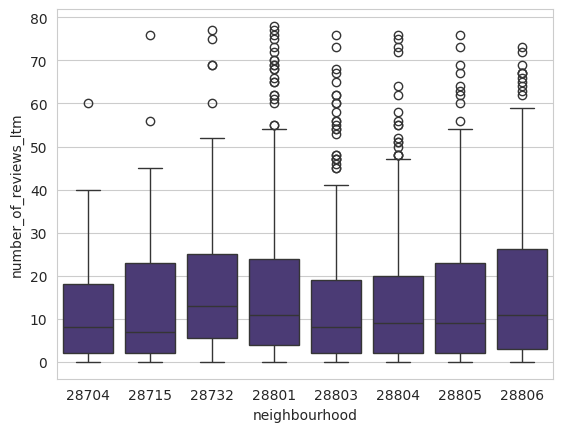

In [21]:
sns.boxplot(data=cleaned_listings, x="neighbourhood", y="number_of_reviews_ltm")


In [18]:
cleaned_listings.info()


<class 'pandas.DataFrame'>
Index: 2117 entries, 0 to 2837
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   price                           2117 non-null   float64
 1   minimum_nights                  2117 non-null   int64  
 2   calculated_host_listings_count  2117 non-null   int64  
 3   availability_365                2117 non-null   int64  
 4   number_of_reviews_ltm           2117 non-null   int64  
 5   days_since_review               2117 non-null   float64
 6   room_type                       2117 non-null   str    
 7   neighbourhood                   2117 non-null   int64  
dtypes: float64(2), int64(5), str(1)
memory usage: 179.6 KB


## Multivariate Analysis

In [19]:
cleaned_listings = listings[NUMERIC_COLUMNS].drop(
    columns=[
        "number_of_reviews",
        "reviews_per_month",
        "review_year",
        "review_month",
    ]
)

cleaned_listings["room_type"] = listings["room_type"]
cleaned_listings["neighbourhood"] = listings["neighbourhood"]

cleaned_listings = cleaned_listings[
    (cleaned_listings["price"] < cleaned_listings["price"].quantile(0.99))
    & (
        cleaned_listings["minimum_nights"]
        < cleaned_listings["minimum_nights"].quantile(0.99)
    )
    & (
        cleaned_listings["number_of_reviews_ltm"]
        < cleaned_listings["number_of_reviews_ltm"].quantile(0.99)
    )
    & (
        cleaned_listings["days_since_review"]
        < cleaned_listings["days_since_review"].quantile(0.99)
    )
].copy()


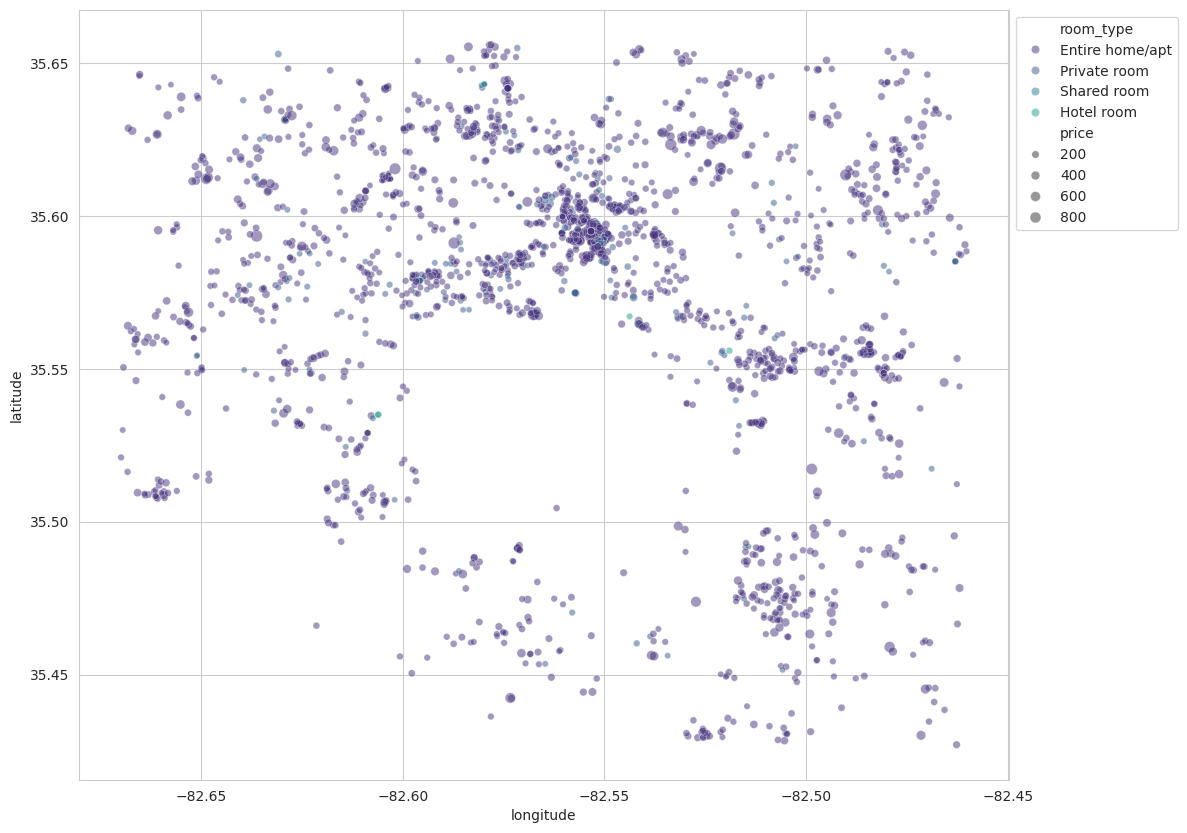

In [20]:
plt.figure(figsize=(12, 10))
sns.scatterplot(
    data=cleaned_listings,
    x="longitude",
    y="latitude",
    size="price",
    hue="room_type",
    alpha=0.5,
)

plt.legend(bbox_to_anchor=(1, 1))


In [ ]:
cleaned_listings.info()


<class 'pandas.DataFrame'>
Index: 2117 entries, 0 to 2837
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   latitude                        2117 non-null   float64
 1   longitude                       2117 non-null   float64
 2   price                           2117 non-null   float64
 3   minimum_nights                  2117 non-null   int64  
 4   calculated_host_listings_count  2117 non-null   int64  
 5   availability_365                2117 non-null   int64  
 6   number_of_reviews_ltm           2117 non-null   int64  
 7   days_since_review               2117 non-null   float64
 8   room_type                       2117 non-null   str    
 9   neighbourhood                   2117 non-null   int64  
dtypes: float64(4), int64(5), str(1)
memory usage: 212.6 KB
